<a href="https://colab.research.google.com/github/bdeekshith066/Optimizing-AI-Compression-Techniques/blob/main/GPT_2_structured_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔧 GPT-2 Structured Pruning: By Team 083

This notebook demonstrates how to apply structured pruning to GPT-2 using PyTorch and HuggingFace. We'll compare model performance, size, and inference time before and after pruning.

---

## ⚙️ 1. Installation

In [ ]:
!pip install transformers datasets accelerate
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 53.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## 🧩 2. Setup & Imports

In [ ]:
import torch
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import time
import matplotlib.pyplot as plt
import numpy as np
from torch.nn.utils import prune
import copy

## 📥 3. Load Pretrained GPT-2 and Tokenizer

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

## 📏 4. Baseline Evaluation (Before Pruning)

In [ ]:
import time

# Set a sample prompt
sample_prompt = "The future of AI in edge computing is"

# Set pad_token to eos_token (required for GPT-2)
tokenizer.pad_token = tokenizer.eos_token

# Tokenize input with padding
inputs = tokenizer(sample_prompt, return_tensors="pt", padding=True)
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]

# Count total trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Generate text and measure inference time
start_time = time.time()
with torch.no_grad():
    outputs = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_length=50,
        pad_token_id=tokenizer.eos_token_id
    )
end_time = time.time()

# Decode the output
baseline_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
baseline_time = end_time - start_time
baseline_params = count_parameters(model)

# Print metrics
print(f"📝 Generated Text: {baseline_output}")
print(f"⚡ Inference Time: {baseline_time:.4f} seconds")
print(f"🪶 Total Parameters: {baseline_params:,}")


📝 Generated Text: The future of AI in edge computing is uncertain. The most promising future is a future where the human brain is the only thing that can learn.

The future of AI in edge computing is uncertain. The most promising future is a future where the
⚡ Inference Time: 6.4122 seconds
🪶 Total Parameters: 124,439,808


## 📏 5. Evaluation with 0-Prune (Model Cloned, No Pruning Applied)

In [ ]:
import copy
from torch.nn.utils import prune

# Step 1: Clone the original model (for consistency in evaluation)
pruned_model = copy.deepcopy(model)

# Step 2: FFN Pruning – No layers specified (empty set)
def prune_ffn_layers_limited(model, amount=0.3, layers_to_prune=set()):
    for name, module in model.named_modules():
        for layer_idx in layers_to_prune:
            if f'transformer.h.{layer_idx}.mlp.c_fc' in name and isinstance(module, torch.nn.Linear):
                prune.l1_unstructured(module, name='weight', amount=amount)

# Call with no layers to prune
prune_ffn_layers_limited(pruned_model, layers_to_prune=set())

# Step 3: Attention Head Pruning – No heads specified
heads_to_prune = {}  # empty dict means no head pruning
pruned_model.prune_heads(heads_to_prune)

# Step 4: Run Inference + Metrics
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

start_time = time.time()
with torch.no_grad():
    outputs = pruned_model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_length=50,
        pad_token_id=tokenizer.eos_token_id
    )
end_time = time.time()

no_prune_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
no_prune_time = end_time - start_time
no_prune_params = count_parameters(pruned_model)

print(f"\n🧠 No-Prune Output:\n{no_prune_output}")
print(f"🪶 Model Params: {no_prune_params:,}")
print(f"⚡ Inference Time: {no_prune_time:.4f} seconds")



🧠 No-Prune Output:
The future of AI in edge computing is uncertain. The most promising future is a future where the human brain is the only thing that can learn.

The future of AI in edge computing is uncertain. The most promising future is a future where the
🪶 Model Params: 124,439,808
⚡ Inference Time: 2.5063 seconds


## 📏 6. Evaluation with 2-Layer FFN Prune + 4 Head Prune Per Layer

In [ ]:
import copy
from torch.nn.utils import prune

# Step 1: Clone the original model
pruned_model = copy.deepcopy(model)

# Step 2: FFN Pruning (only in layers 0 and 1)  -> 40% of the smallest weights to prune (set to zero)
def prune_ffn_layers_limited(model, amount=0.4, layers_to_prune={0, 1}):
    for name, module in model.named_modules():
        for layer_idx in layers_to_prune:
            if f'transformer.h.{layer_idx}.mlp.c_fc' in name and isinstance(module, torch.nn.Linear):
                prune.l1_unstructured(module, name='weight', amount=amount)

prune_ffn_layers_limited(pruned_model)

# Step 3: Attention Head Pruning (only 2 layers, prune heads 0–2) ---> means prune 4 heads (0–3) from each specified layer
heads_to_prune = {layer_idx: set(range(4)) for layer_idx in [0, 1]}
pruned_model.prune_heads(heads_to_prune)


## 📏 7. Run Inference + Collect Metrics (After Pruning)

In [ ]:
# Count total trainable parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Run inference on pruned model
start_time = time.time()
with torch.no_grad():
    outputs = pruned_model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_length=50,
        pad_token_id=tokenizer.eos_token_id
    )
end_time = time.time()

# Decode and measure performance
pruned_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
pruned_time = end_time - start_time
pruned_params = count_parameters(pruned_model)

print(f"\n🧠 Pruned Model Output:\n{pruned_output}")
print(f"🪶 Pruned Model Params: {pruned_params:,}")
print(f"⚡ Inference Time After Pruning: {pruned_time:.4f} seconds")



🧠 Pruned Model Output:
The future of AI in edge computing is a matter of debate. The question is whether it will be a good thing or a bad thing.

The answer is a good thing.

The future of AI in edge computing is a matter of
🪶 Pruned Model Params: 122,865,408
⚡ Inference Time After Pruning: 2.4163 seconds


## 📊 8. Comparison Plot: Before vs After Pruning

/tmp/ipython-input-9-2643682889.py:24: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


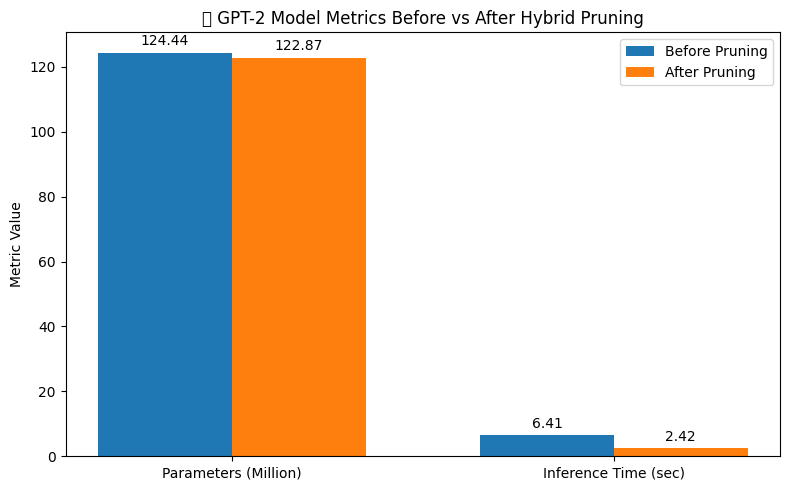

🔹 Before Pruning:
The future of AI in edge computing is uncertain. The most promising future is a future where the human brain is the only thing that can learn.

The future of AI in edge computing is uncertain. The most promising future is a future where the

--------------------------------------------------------------------------------
🔸 After Pruning: 
 FFN Pruning: 40% of smallest weights pruned (L1) in layers 0 & 1 
 Attention Head Pruning: 4 heads (0–3) pruned from layers 0 & 1 
The future of AI in edge computing is a matter of debate. The question is whether it will be a good thing or a bad thing.

The answer is a good thing.

The future of AI in edge computing is a matter of


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Parameters (Million)', 'Inference Time (sec)']
before = [baseline_params / 1e6, baseline_time]
after = [pruned_params / 1e6, pruned_time]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, before, width, label='Before Pruning')
rects2 = ax.bar(x + width/2, after, width, label='After Pruning')

# Labels and titles
ax.set_ylabel('Metric Value')
ax.set_title('📉 GPT-2 Model Metrics Before vs After Hybrid Pruning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()


print(f"🔹 Before Pruning:\n{baseline_output}")
print("\n" + "-"*80)
print(f"🔸 After Pruning: \n FFN Pruning: 40% of smallest weights pruned (L1) in layers 0 & 1 \n Attention Head Pruning: 4 heads (0–3) pruned from layers 0 & 1 \n{pruned_output}")
print("="*80)

